# Notebook 90 — conditional Hough patch only on detected overweight frames

This notebook detects candidate high-angle-overweight frames and patches only those frames by swapping the baseline Hough output to the notebook-only `angle_profile_localmax` variant.

In [1]:
from pathlib import Path
import subprocess
import sys
from IPython.display import Markdown, Image, display

ROOT = Path.cwd().resolve()
if not (ROOT / 'scripts').exists():
    ROOT = ROOT.parent
SCRIPT = ROOT / 'scripts' / 'evaluate_conditional_hough_patch.py'
OUT = ROOT / 'results' / 'notebook90_conditional_hough_patch'
print(f'Project root: {ROOT}')
print(f'Script: {SCRIPT}')
print(f'Output directory: {OUT}')

Project root: /Users/grosbedou/PycharmProjects/NDORMS
Script: /Users/grosbedou/PycharmProjects/NDORMS/scripts/evaluate_conditional_hough_patch.py
Output directory: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook90_conditional_hough_patch


In [2]:
completed = subprocess.run([sys.executable, str(SCRIPT)], check=True)
completed

Loading cached localmax entries from /Users/grosbedou/PycharmProjects/NDORMS/results/notebook90_conditional_hough_patch/angle_profile_localmax_entries.pkl
Evaluating conditional patch variant: baseline_current
Evaluating conditional patch variant: oracle_overweight_to_localmax
Evaluating conditional patch variant: heuristic_mass10_gap6_to_localmax
Evaluating conditional patch variant: heuristic_mass10_gap4_to_localmax
Evaluating conditional patch variant: heuristic_localmax_gap10_to_localmax
# Notebook 90 — conditional Hough patch only on detected overweight frames

Started from the cached full-sequence baseline masks/candidates, then patched only selected frames by swapping baseline Hough output to the notebook-only `angle_profile_localmax` variant.

This notebook separates two questions:

1. Is there an upper bound if we patch only the true high-angle-overweight frames?
2. Can Python-only detector rules find enough of those frames to improve full-sequence parity without hurting the r

CompletedProcess(args=['/Library/Developer/CommandLineTools/usr/bin/python3', '/Users/grosbedou/PycharmProjects/NDORMS/scripts/evaluate_conditional_hough_patch.py'], returncode=0)

In [3]:
display(Markdown((OUT / 'notebook90_summary.md').read_text()))

# Notebook 90 — conditional Hough patch only on detected overweight frames

Started from the cached full-sequence baseline masks/candidates, then patched only selected frames by swapping baseline Hough output to the notebook-only `angle_profile_localmax` variant.

This notebook separates two questions:

1. Is there an upper bound if we patch only the true high-angle-overweight frames?
2. Can Python-only detector rules find enough of those frames to improve full-sequence parity without hurting the rest?

## Key findings

- The best raw-alpha RMSE is `oracle_overweight_to_localmax` at 2.2963 deg, versus 2.8086 deg for baseline.
- The best downstream FL RMSE is `heuristic_mass10_gap4_to_localmax` at 1.2569 mm, versus 2.0116 mm for baseline.
- Oracle overweight subset size is 128 frames.

## Interpretation

- If the oracle subset helps but the Python-only detector rules do not, then the conditional patch idea is directionally right but the detector is not yet good enough.
- If a Python-only detector also helps full-sequence FL/parity, that gives us a more credible code-facing path than a global Hough patch.
- Comparing conservative and broader mass-gap detectors tells us whether the high-angle-overweight pattern is sparse and sharp or diffuse and easy to over-trigger.

- Raw metrics CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook90_conditional_hough_patch/conditional_raw_metrics.csv`
- Persistence metrics CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook90_conditional_hough_patch/conditional_persistence_metrics.csv`
- Downstream metrics CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook90_conditional_hough_patch/conditional_downstream_metrics.csv`
- Detector stats CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook90_conditional_hough_patch/conditional_detector_stats.csv`
- Detector feature table CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook90_conditional_hough_patch/detector_feature_table.csv`
- Combined summary CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook90_conditional_hough_patch/conditional_variant_summary.csv`
- Per-frame CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook90_conditional_hough_patch/conditional_per_frame.csv`
- Summary plot: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook90_conditional_hough_patch/conditional_patch_summary.png`
- Trace plot: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook90_conditional_hough_patch/conditional_patch_traces.png`


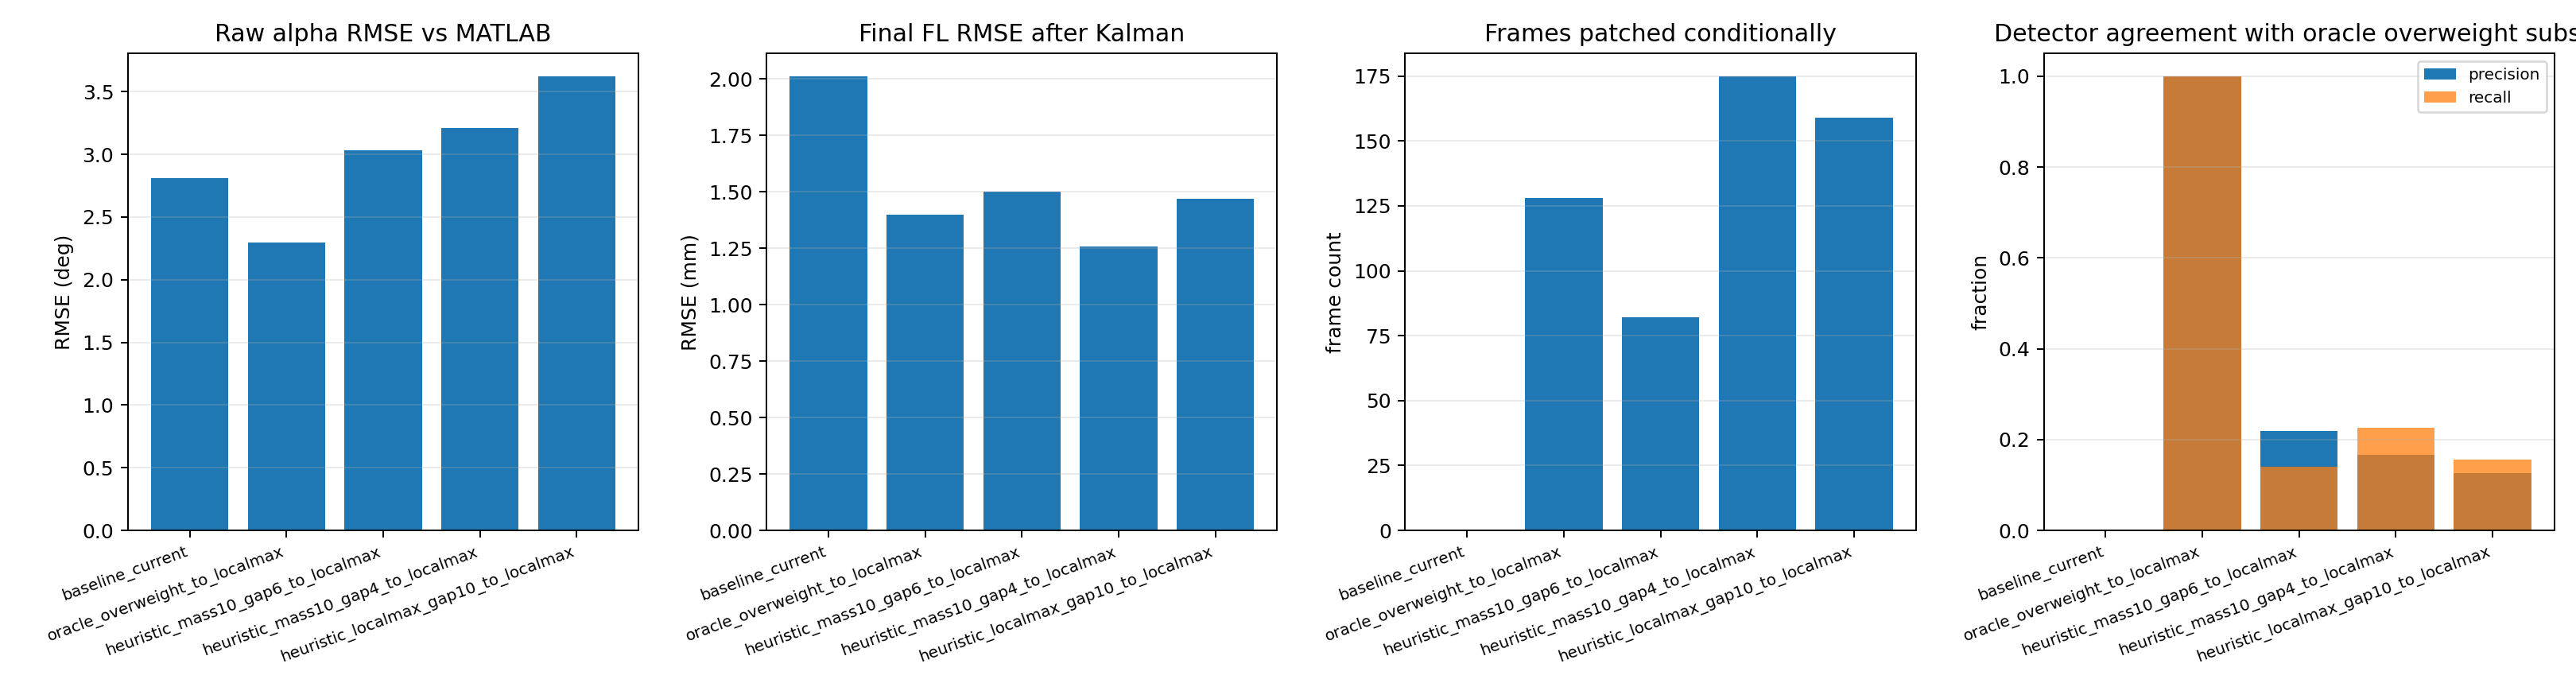

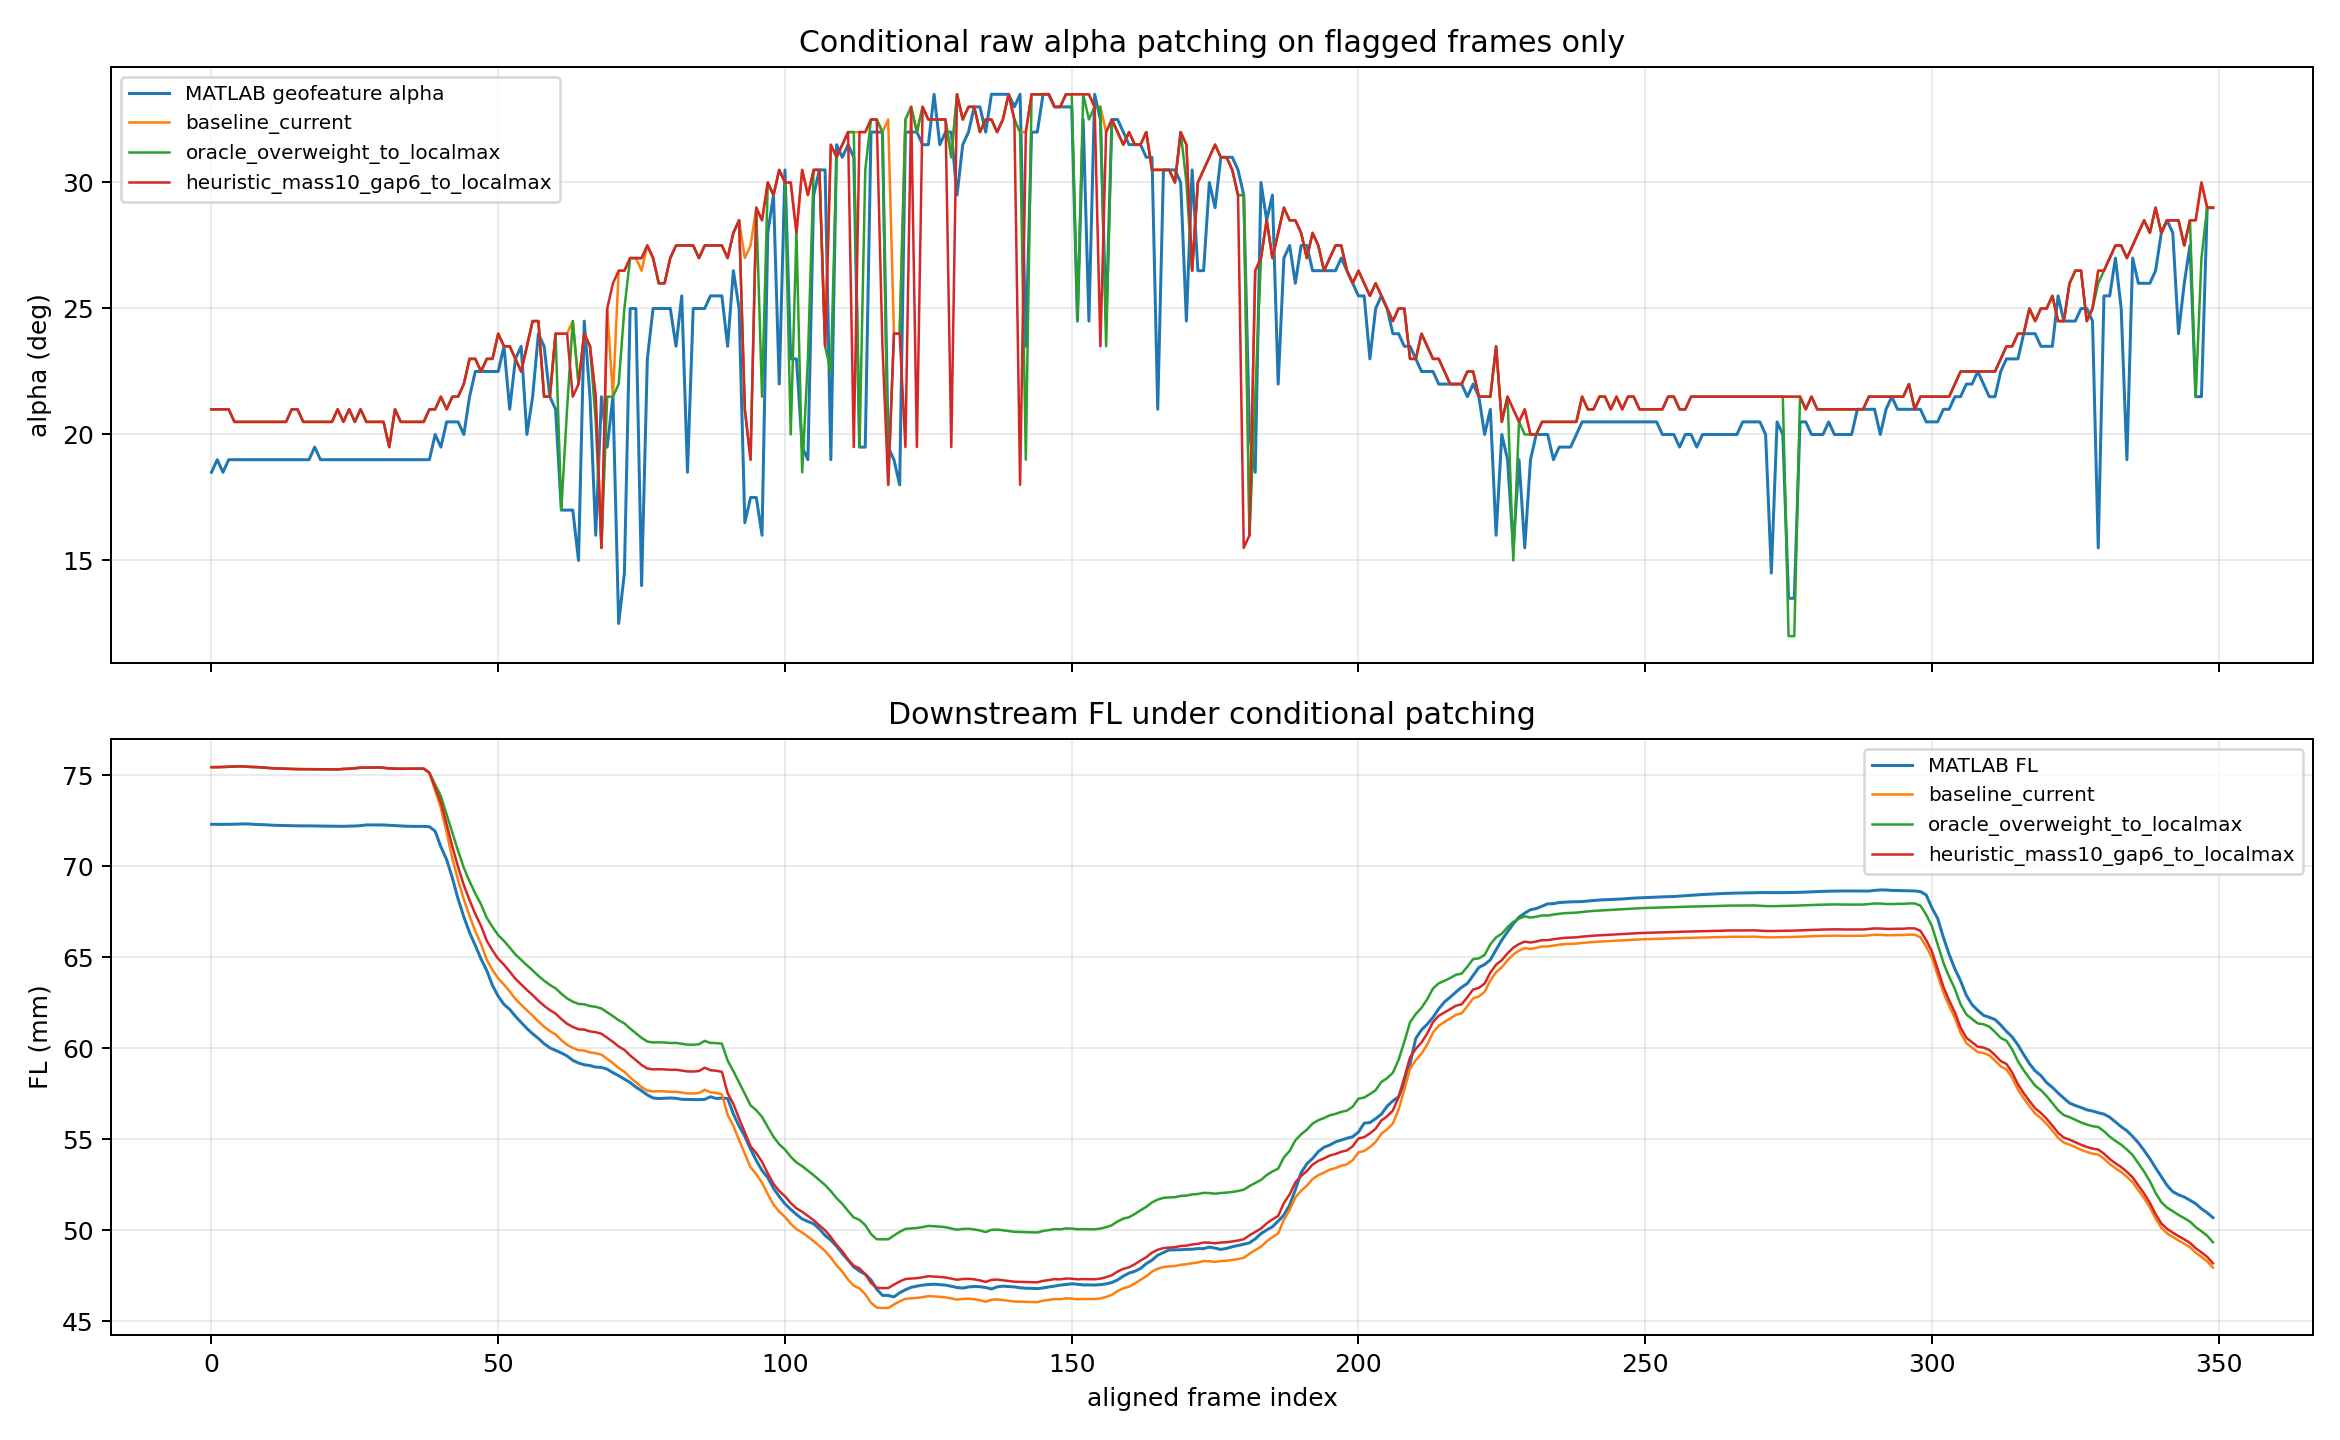

In [4]:
display(Image(filename=str(OUT / 'conditional_patch_summary.png')))
display(Image(filename=str(OUT / 'conditional_patch_traces.png')))